In [2]:
import pandas as pd
import numpy as np

print("Notebook working")

Notebook working


In [3]:
import pandas as pd

df = pd.read_csv("../data/student_data.csv")

df.head()

,hours_studied,attendance,sleep_hours,previous_score,internet_usage,final_exam_score
0,5,90,7,75,2,80
1,3,80,6,65,4,68
2,8,95,7,88,1,92
3,2,60,5,50,5,55
4,6,85,6,78,3,82


In [4]:
df.shape

(20, 6)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   hours_studied     20 non-null     int64
 1   attendance        20 non-null     int64
 2   sleep_hours       20 non-null     int64
 3   previous_score    20 non-null     int64
 4   internet_usage    20 non-null     int64
 5   final_exam_score  20 non-null     int64
dtypes: int64(6)
memory usage: 1.1 KB


In [6]:
df.isnull().sum()

hours_studied       0
attendance          0
sleep_hours         0
previous_score      0
internet_usage      0
final_exam_score    0
dtype: int64

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv("../data/student_data.csv")
df.head()

,hours_studied,attendance,sleep_hours,previous_score,internet_usage,final_exam_score
0,5,90,7,75,2,80
1,3,80,6,65,4,68
2,8,95,7,88,1,92
3,2,60,5,50,5,55
4,6,85,6,78,3,82


In [9]:
df.describe()

,hours_studied,attendance,sleep_hours,previous_score,internet_usage,final_exam_score
count,20.00000,20.000000,20.00000,20.000000,20.000000,20.000000
mean,5.20000,81.200000,6.35000,71.700000,2.850000,76.050000
std,2.35305,14.259254,1.03999,15.131355,1.496487,15.045457
min,1.00000,50.000000,4.00000,40.000000,1.000000,45.000000
25%,3.75000,71.500000,6.00000,62.250000,2.000000,66.500000
50%,5.00000,86.500000,6.50000,74.500000,2.500000,79.500000
75%,7.00000,91.250000,7.00000,83.500000,4.000000,88.250000
max,9.00000,98.000000,8.00000,92.000000,6.000000,96.000000


In [10]:
df.corr()

,hours_studied,attendance,sleep_hours,previous_score,internet_usage,final_exam_score
hours_studied,1.000000,0.927370,0.916212,0.970004,-0.947614,0.973461
attendance,0.927370,1.000000,0.949744,0.982126,-0.965378,0.984446
sleep_hours,0.916212,0.949744,1.000000,0.936812,-0.945205,0.940647
previous_score,0.970004,0.982126,0.936812,1.000000,-0.966684,0.998103
internet_usage,-0.947614,-0.965378,-0.945205,-0.966684,1.000000,-0.969748
final_exam_score,0.973461,0.984446,0.940647,0.998103,-0.969748,1.000000


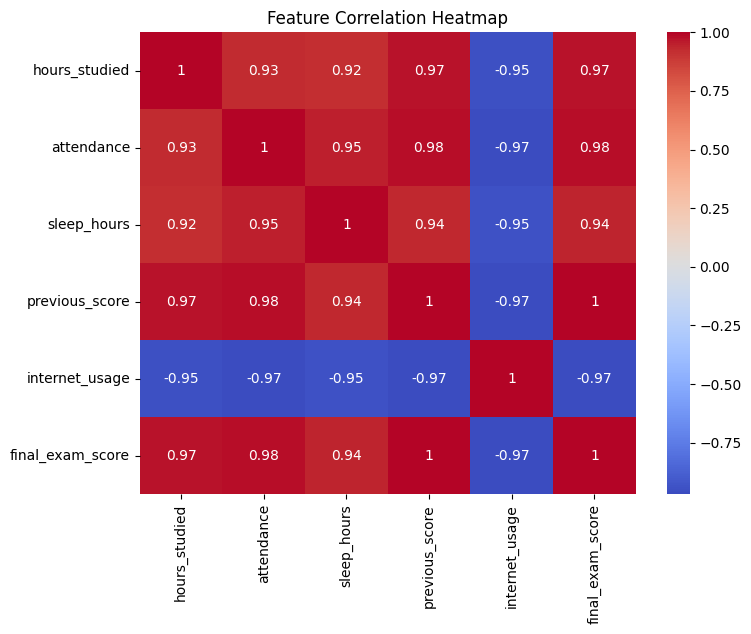

In [11]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

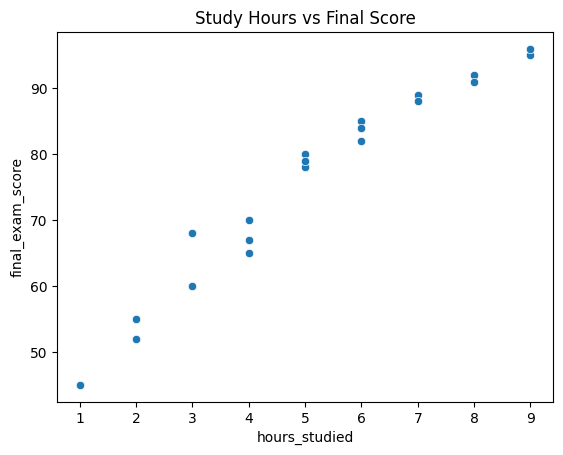

In [12]:
sns.scatterplot(x=df["hours_studied"], y=df["final_exam_score"])
plt.title("Study Hours vs Final Score")
plt.show()

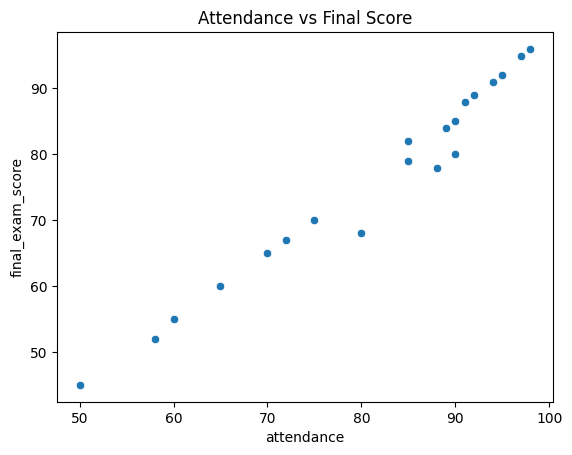

In [13]:
sns.scatterplot(x=df["attendance"], y=df["final_exam_score"])
plt.title("Attendance vs Final Score")
plt.show()

In [14]:
X = df.drop("final_exam_score", axis=1)
y = df["final_exam_score"]

print(X.head())
print(y.head())

   hours_studied  attendance  sleep_hours  previous_score  internet_usage
0              5          90            7              75               2
1              3          80            6              65               4
2              8          95            7              88               1
3              2          60            5              50               5
4              6          85            6              78               3
0    80
1    68
2    92
3    55
4    82
Name: final_exam_score, dtype: int64


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (16, 5)
Testing data: (4, 5)


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
from sklearn.linear_model import LinearRegression

In [18]:
model = LinearRegression()

In [19]:
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
y_pred = model.predict(X_test_scaled)

print(y_pred)

[80.70037158 79.21946965 52.61069561 70.94522435]


In [21]:
import pandas as pd

comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison

,Actual,Predicted
0,80,80.700372
17,79,79.219470
15,52,52.610696
1,68,70.945224


In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [23]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 1.118940295188299


In [24]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 2.396495716184737


In [25]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.9811577732388423


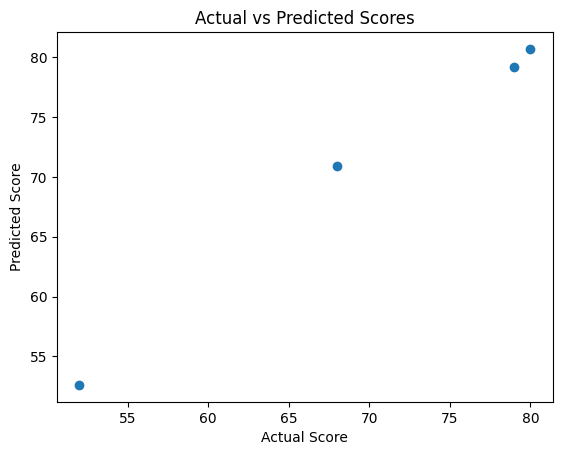

In [26]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Scores")
plt.show()

In [27]:
import joblib

In [28]:
joblib.dump(model, "../model/student_score_model.pkl")

['../model/student_score_model.pkl']